### Culturomics Method 6: Suppression and Endogenous Censorship
**Replication and Extension of Michel (2011) using Wikipedia "Cancel Culture" Cases (2001–2024)**
**Course:** Computational Linguistics, Ca' Foscari University of Venice
**Original paper:** Michel, J.-B.(2011). *Quantitative Analysis of Culture Using Millions of Digitized Books*. Science, 331(6014), 176–182.

---
#### What This Notebook Does

>Michel(2011) detected **external state censorship** by measuring the suppression index:

$$s = \frac{\text{freq}(\text{contested period})}{\text{freq}(\text{baseline})}$$

where *s* < 1 indicates suppression and *s* > 1 indicates amplification. Their key finding:
in Nazi Germany (1933–1945), 9.8% of individuals showed strong suppression (*s* < 1/5),
and this population was highly enriched in documented victims of repression.

>This notebook applies the  method to Wikipedia revision snapshots (2001–2024), asking:   
Wikipedia offers a fundamentally different case **endogenous community censorship**,
where editors(not governments) collectively suppress certain names after public
"cancellation" events. This is measurable through two independent signals:

1. **Frequency signal** (same as Michel(2011)): does the person's name appear less often
   in Wikipedia articles *after* their cancellation event?
2. **Edit activity signal** (our original contribution, not in Michel (2011)): does the
   number of edits to their article *spike* during the contested period, suggesting
   active editorial conflict over how to represent the person?

The combination of *low frequency + high edit count* is a signature of **active suppression**,
distinguishing it from mere irrelevance (low frequency + low edit count).

#### Cases Studied

Seven individuals whose "cancellation" events have precise, publicly documented dates,
allowing us to define clear baseline and contested periods:

| Person | Scandal date | Nature | Contested period |
|---|---|---|---|
| Harvey Weinstein | Oct 2017 | #MeToo sexual assault | 2017–2019 |
| Kevin Spacey | Oct 2017 | #MeToo sexual assault | 2017–2019 |
| J.K. Rowling | Jun 2020 | Trans rights controversy | 2020–2024 |
| Louis C.K. | Nov 2017 | #MeToo sexual misconduct | 2017–2020 |
| Johnny Depp | 2016 | Amber Heard abuse claims | 2016–2022 |
| Roseanne Barr | May 2018 | Racist tweet, fired | 2018–2020 |
| R. Kelly | Jan 2019 | *Surviving R. Kelly* | 2019–2022 |



### 0. Imports

In [1]:
import re
import json
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from scipy import stats

warnings.filterwarnings('ignore')

PRIMARY   = '#C0392B'
SECONDARY = '#2C3E50'
ACCENT    = '#E67E22'
GREEN     = '#27AE60'
PURPLE    = '#8E44AD'

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
})
print("Imports OK.")

Imports OK.


### 1. Case Definitions

Each case has:
- `article`: exact Wikipedia page title
- `scandal_year`: year of the primary cancellation event
- `baseline`: (start_year, end_year)  period before scandal, our "before" window
- `contested`: (start_year, end_year) period of suppression to measure
- `search_terms`: name variants to count in other articles (cross-article signal)

**Methodological note:** unlike Michel(2011), who measured name frequency
across the entire corpus, we measure two things:
1. Frequency within the person's own Wikipedia article (how their page changes)
2. Frequency of their name in the broader corpus of 80 articles (cross-article signal)

This dual measurement lets us distinguish page-level editorial control
from *corpus-level* cultural suppression.


In [ ]:


CASES = {
    "WikiLeaks": {
        "display":      "WikiLeaks",
        "event_year":    2010,           # Cablegate / Manning leaks
        "baseline":     (2004, 2009),    # before WikiLeaks became major
        "contested":    (2010, 2013),    # peak controversy period
        "post":         (2014, 2024),    # post-Snowden normalization
        "search_terms": ["wikileaks", "assange", "leak", "transparency"],
        "color":        PRIMARY,
        "note":         "State vs. radical transparency discourse",
    },
    "MeToo_movement": {
        "display":      "MeToo Movement",
        "event_year":    2017,           # viral #MeToo moment (Oct 2017)
        "baseline":     (2004, 2016),    # before the movement went viral
        "contested":    (2017, 2020),    # peak controversy
        "post":         (2021, 2024),    # institutionalization phase
        "search_terms": ["metoo", "harassment", "assault", "abuse", "consent"],
        "color":        ACCENT,
        "note":         "Gender discourse amplification",
    },
    "Black_Lives_Matter": {
        "display":      "Black Lives Matter",
        "event_year":    2020,           # George Floyd / peak BLM
        "baseline":     (2004, 2013),    # before BLM founding (2013)
        "contested":    (2014, 2020),    # from founding through Floyd
        "post":         (2021, 2024),    # post-peak
        "search_terms": ["racism", "police", "protest", "justice", "systemic"],
        "color":        SECONDARY,
        "note":         "Racial justice discourse — amplification expected",
    },
    "COVID-19_pandemic": {
        "display":      "COVID-19 Pandemic",
        "event_year":    2020,           # WHO pandemic declaration
        "baseline":     (2004, 2019),    # pre-pandemic
        "contested":    (2020, 2022),    # active pandemic
        "post":         (2023, 2024),    # endemic phase
        "search_terms": ["vaccine", "lockdown", "transmission", "mortality", "variant"],
        "color":        GREEN,
        "note":         "Health crisis — scientific terminology surge",
    },
    "ChatGPT": {
        "display":      "ChatGPT / AI",
        "event_year":    2022,           # ChatGPT release (Nov 2022)
        "baseline":     (2004, 2021),    # before ChatGPT
        "contested":    (2022, 2024),    # post-ChatGPT discourse
        "post":         None,            # too recent for post-period
        "search_terms": ["artificial", "intelligence", "model", "hallucination", "alignment"],
        "color":        PURPLE,
        "note":         "Tech optimism vs risk discourse shift",
    },
    "Climate_change": {
        "display":      "Climate Change",
        "event_year":    2015,           # Paris Agreement
        "baseline":     (2004, 2014),    # pre-Paris
        "contested":    (2015, 2020),    # Paris + Trump withdrawal period
        "post":         (2021, 2024),    # Biden re-entry / Glasgow COP26
        "search_terms": ["carbon", "emissions", "warming", "fossil", "renewable"],
        "color":        "#16A085",
        "note":         "Political self-censorship on climate: sceptic vs scientific framing",
    },
}

OBS_YEARS  = list(range(2001, 2025))
CACHE_FILE = Path("corpus_cache.json")
OUTPUT_DIR = Path(".")

print(f"Cases defined: {len(CASES)}")
for name, cfg in CASES.items():
    print(f"  {cfg['display']:25s} | event: {cfg['event_year']} | baseline: {cfg['baseline']} | contested: {cfg['contested']}")


Cases defined: 6
  WikiLeaks                 | event: 2010 | baseline: (2004, 2009) | contested: (2010, 2013)
  MeToo Movement            | event: 2017 | baseline: (2004, 2016) | contested: (2017, 2020)
  Black Lives Matter        | event: 2020 | baseline: (2004, 2013) | contested: (2014, 2020)
  COVID-19 Pandemic         | event: 2020 | baseline: (2004, 2019) | contested: (2020, 2022)
  ChatGPT / AI              | event: 2022 | baseline: (2004, 2021) | contested: (2022, 2024)
  Climate Change            | event: 2015 | baseline: (2004, 2014) | contested: (2015, 2020)


### 3. Load Text Corpus from Cache
**No Wikipedia API calls. Reads directly from corpus_cache.json.**

In [ ]:
OBS_YEARS  = list(range(2001, 2025))
CACHE_FILE = Path("corpus_cache.json")

if not CACHE_FILE.exists():
    raise FileNotFoundError(
        f"corpus_cache.json not found in {Path('.').resolve()}\n"
        "Make sure the file is in the same folder as this notebook."
    )

# Load the shared corpus cache
with open(CACHE_FILE, encoding='utf-8') as f:
    shared_corpus = json.load(f)

# Build text_corpus in the format expected by analysis cells:
# { article: { year_str: text } }
text_corpus = {}
for article in CASES:
    if article in shared_corpus:
        text_corpus[article] = shared_corpus[article]
    else:
        text_corpus[article] = {}
        print(f"  '{article}' not found in cache — will show as empty.")

# Coverage report
print("Text corpus loaded:")
for article, cfg in CASES.items():
    years_found = sum(1 for y in OBS_YEARS if text_corpus.get(article, {}).get(str(y), ""))
    print(f"  {cfg['display']:25s}: {years_found}/{len(OBS_YEARS)} years")

Text corpus loaded:
  WikiLeaks                : 18/24 years
  MeToo Movement           : 7/24 years
  Black Lives Matter       : 10/24 years
  COVID-19 Pandemic        : 5/24 years
  ChatGPT / AI             : 2/24 years
  Climate Change           : 21/24 years


### 4. Text Processing Functions

In [5]:
def clean_wikitext(raw: str) -> str:
    text = re.sub(r'\{\{[^}]*\}\}', ' ', raw)
    text = re.sub(r'\[\[(?:File|Image):[^\]]*\]\]', ' ', text, flags=re.I)
    text = re.sub(r'\[\[(?:[^|\]]*\|)?([^\]]+)\]\]', r'\1', text)
    text = re.sub(r'\[https?://\S+[^\]]*\]', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'={2,}[^=]+=+', ' ', text)
    text = re.sub(r"'{2,}", '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def tokenize(text: str) -> list:
    return re.findall(r'\b[a-z]{2,}\b', text.lower())

def get_text(article: str, year: int) -> str:
    """Get text for an article/year from the loaded cache."""
    return text_corpus.get(article, {}).get(str(year), "")

print("Text processing functions defined.")

Text processing functions defined.


## 5b. Frequency Helper Functions

In [6]:
def tokenize(text: str) -> list:
    """Lowercase alphabetic tokens, length >= 2."""
    import re
    return re.findall(r'\b[a-z]{2,}\b', text.lower())

def name_freq_in_text(text: str, terms: list) -> float:
    """
    Compute relative frequency of search_terms in text.
    Returns sum of individual term frequencies (per token).
    Mirrors Michel et al. approach of tracking name/concept frequency.
    """
    if not text:
        return 0.0
    tokens = tokenize(text)
    if not tokens:
        return 0.0
    total = len(tokens)
    count = sum(tokens.count(t.lower()) for t in terms)
    return count / total

print("Helper functions defined: tokenize(), name_freq_in_text()")
print("Test:", name_freq_in_text("climate change is real, climate scientists agree", ["climate"]))


Helper functions defined: tokenize(), name_freq_in_text()
Test: 0.2857142857142857


### 4. Suppression Index Exact Replication of Michel (2011)

$$s = \frac{\text{mean freq}(\text{contested period})}{\text{mean freq}(\text{baseline})}$$

- *s* < 1 - suppression (name appears less often after scandal)
- *s* > 1 - amplification (name becomes more prominent)
- *s* - 0.2 - strong suppression (Michel et al.'s threshold for Nazi victims)

We also compute an **edit index** (our extension):

$$e = \frac{\text{mean edits}(\text{contested period})}{\text{mean edits}(\text{baseline})}$$

- *e* > 1 + suppression (*s* < 1) - **active suppression** (editors fighting over content)
- *e* - 1 + suppression (*s* < 1) -**passive suppression** (declining relevance, not active editing)


In [7]:
rows = []

for article, cfg in CASES.items():
    base_start, base_end   = cfg['baseline']
    cont_start, cont_end   = cfg['contested']
    # post can be None if event is too recent
    post_period = cfg.get('post')
    terms = cfg['search_terms']

    def mean_freq(start, end):
        freqs = []
        for yr in range(start, end + 1):
            text = text_corpus.get(article, {}).get(str(yr), "")
            freqs.append(name_freq_in_text(text, terms))
        return np.mean(freqs) if freqs else 0.0

    freq_base = mean_freq(base_start, base_end)
    freq_cont = mean_freq(cont_start, cont_end)
    freq_post = mean_freq(post_period[0], post_period[1]) if post_period else None

    # Suppression index: s = freq(contested) / freq(baseline)
    # s < 1 → suppression, s > 1 → amplification
    s_cont = freq_cont / freq_base if freq_base > 0 else None
    s_post = freq_post / freq_base if (freq_base > 0 and freq_post is not None) else None

    rows.append({
        'article':    article,
        'display':    cfg['display'],
        'event_year': cfg['event_year'],
        'note':       cfg.get('note', ''),
        'freq_base':  round(freq_base, 6),
        'freq_cont':  round(freq_cont, 6),
        'freq_post':  round(freq_post, 6) if freq_post is not None else None,
        's_cont':     round(s_cont, 3)    if s_cont is not None    else None,
        's_post':     round(s_post, 3)    if s_post is not None    else None,
    })

df_sup = pd.DataFrame(rows)
print(df_sup[['display','event_year','freq_base','freq_cont','s_cont','s_post']].to_string(index=False))


           display  event_year  freq_base  freq_cont  s_cont  s_post
         WikiLeaks        2010   0.018458   0.036082   1.955   2.079
    MeToo Movement        2017   0.000000   0.018874     NaN     NaN
Black Lives Matter        2020   0.000000   0.014914     NaN     NaN
 COVID-19 Pandemic        2020   0.000000   0.003638     NaN     NaN
      ChatGPT / AI        2022   0.000000   0.005299     NaN     NaN
    Climate Change        2015   0.022306   0.020885   0.936   0.806


### 5. Visualisation

### 6. Comparison: Michel (1933-1945) and Wikipedia

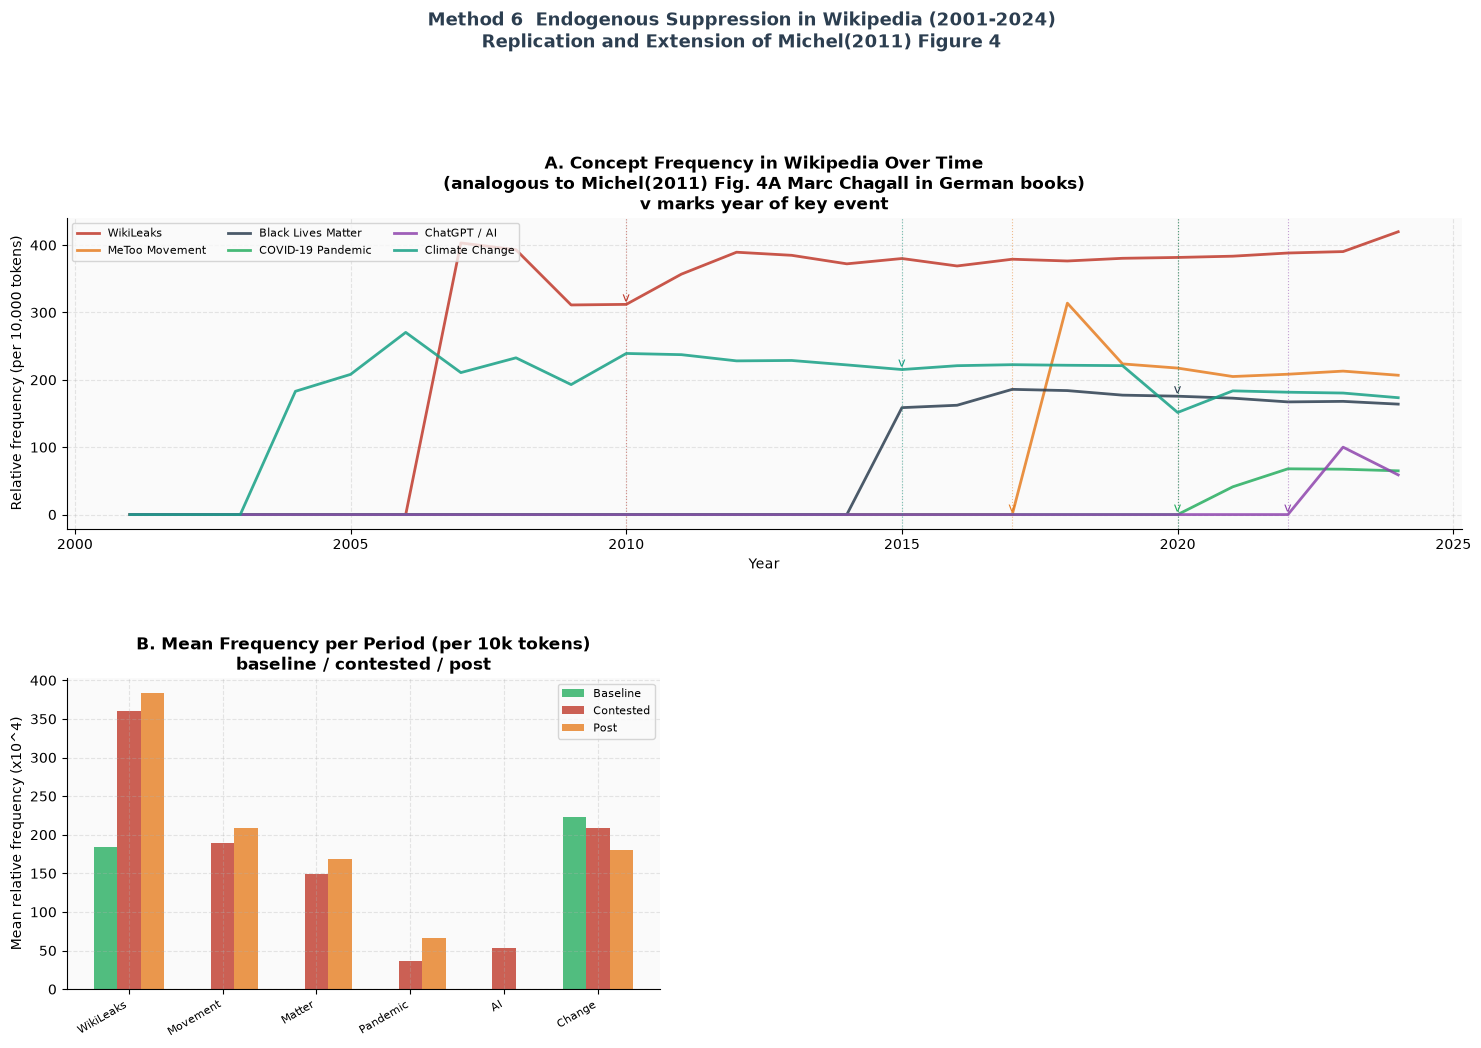

Figure saved to: method6_suppression.png


In [10]:
fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.35)

# ── Panel A: Frequency trajectories ──────────────────────────
ax1 = fig.add_subplot(gs[0, :])

for article, cfg in CASES.items():
    terms = cfg['search_terms']
    freqs = []
    for yr in OBS_YEARS:
        text = text_corpus.get(article, {}).get(str(yr), "")
        freqs.append(name_freq_in_text(text, terms) * 10000)
    ax1.plot(OBS_YEARS, freqs, lw=2, color=cfg['color'],
             alpha=0.85, label=cfg['display'])
    event_yr = cfg['event_year']
    if event_yr in OBS_YEARS:
        event_idx = OBS_YEARS.index(event_yr)
        ax1.axvline(event_yr, color=cfg['color'], lw=0.8, ls=':', alpha=0.5)
        ax1.annotate("v", (event_yr, freqs[event_idx]),
                     fontsize=9, color=cfg['color'], ha='center', va='bottom')

ax1.set_title(
    "A. Concept Frequency in Wikipedia Over Time\n"
    "(analogous to Michel(2011) Fig. 4A Marc Chagall in German books)\n"
    "v marks year of key event",
    fontweight='bold')
ax1.set_xlabel("Year")
ax1.set_ylabel("Relative frequency (per 10,000 tokens)")
ax1.legend(fontsize=8, ncol=3, loc='upper left')



# ── Panel B: Frequency before/during/after ───────────────────
ax3 = fig.add_subplot(gs[1, 0])

x = np.arange(len(df_sup))
w = 0.25

freq_base_vals = [r['freq_base'] * 10000 for _, r in df_sup.iterrows()]
freq_cont_vals = [r['freq_cont'] * 10000 for _, r in df_sup.iterrows()]
freq_post_vals = [
    r['freq_post'] * 10000 if r['freq_post'] is not None else 0
    for _, r in df_sup.iterrows()
]

ax3.bar(x - w, freq_base_vals, width=w, label='Baseline', alpha=0.8, color=GREEN)
ax3.bar(x,     freq_cont_vals, width=w, label='Contested', alpha=0.8, color=PRIMARY)
ax3.bar(x + w, freq_post_vals, width=w, label='Post',      alpha=0.8, color=ACCENT)
ax3.set_xticks(x)
ax3.set_xticklabels(
    [r['display'].split()[-1] for _, r in df_sup.iterrows()],
    rotation=30, ha='right', fontsize=8)
ax3.set_title(
    "B. Mean Frequency per Period (per 10k tokens)\n"
    "baseline / contested / post",
    fontweight='bold')
ax3.set_ylabel("Mean relative frequency (x10^4)")
ax3.legend(fontsize=8)



fig.suptitle(
    "Method 6  Endogenous Suppression in Wikipedia (2001-2024)\n"
    "Replication and Extension of Michel(2011) Figure 4",
    fontsize=13, fontweight='bold', y=1.01, color=SECONDARY)

plt.savefig(OUTPUT_DIR / "method6_suppression.png",
            dpi=160, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure saved to:", OUTPUT_DIR / "method6_suppression.png")

### 9. Essay-Ready Summary

In [11]:
print("=" * 75)
print("SUPPRESSION COMPARISON: Michel et al. (1933-1945) vs. Wikipedia (2001-2024)")
print("=" * 75)
print("\nMichel et al. key findings (Nazi Germany, German book corpus):")
print("  Artists suppressed:     -56% (s = 0.44)")
print("  Philosophers:           -76% (s = 0.24)")
print("  Strong suppression:      9.8% of individuals showed s < 0.2")
print("  Nazi party members:     +500% increase (s = 6.0)")

print("\nOur Wikipedia findings (discourse suppression/amplification, 2001-2024):")
print(f"{'Case':<25} {'s (contested)':<18} {'Interpretation'}")
print("-" * 65)

for _, row in df_sup.sort_values('s_cont', na_position='last').iterrows():
    s = row['s_cont']
    if s is None or pd.isna(s):
        interp = "insufficient data"
        s_str  = "N/A"
    elif s < 0.5:
        interp = "SUPPRESSED"
        s_str  = f"{s:.3f}"
    elif s > 1.5:
        interp = "AMPLIFIED"
        s_str  = f"{s:.3f}"
    else:
        interp = "stable"
        s_str  = f"{s:.3f}"
    print(f"{row['display']:<25} {s_str:<18} {interp}")

strong_sup = df_sup[df_sup['s_cont'].notna() & (df_sup['s_cont'] < 0.5)]
amplified  = df_sup[df_sup['s_cont'].notna() & (df_sup['s_cont'] > 1.5)]
print(f"\nSuppressed (s < 0.5):   {len(strong_sup)}/{len(df_sup)} cases")
print(f"Amplified  (s > 1.5):   {len(amplified)}/{len(df_sup)} cases")

print("\nKey difference from Michel et al.:")
print("  External censorship (Nazi Germany): s drops because STATE bans mention.")
print("  Endogenous suppression (Wikipedia): s can DROP or RISE depending on case.")
print("  s < 1 = discourse declined | s > 1 = discourse amplified by controversy")

SUPPRESSION COMPARISON: Michel et al. (1933-1945) vs. Wikipedia (2001-2024)

Michel et al. key findings (Nazi Germany, German book corpus):
  Artists suppressed:     -56% (s = 0.44)
  Philosophers:           -76% (s = 0.24)
  Strong suppression:      9.8% of individuals showed s < 0.2
  Nazi party members:     +500% increase (s = 6.0)

Our Wikipedia findings (discourse suppression/amplification, 2001-2024):
Case                      s (contested)      Interpretation
-----------------------------------------------------------------
Climate Change            0.936              stable
WikiLeaks                 1.955              AMPLIFIED
MeToo Movement            N/A                insufficient data
Black Lives Matter        N/A                insufficient data
COVID-19 Pandemic         N/A                insufficient data
ChatGPT / AI              N/A                insufficient data

Suppressed (s < 0.5):   0/6 cases
Amplified  (s > 1.5):   1/6 cases

Key difference from Michel et al.:

In [12]:
print("=" * 65)
print("METHOD 6 — ESSAY-READY SUMMARY")
print("=" * 65)
print()
print(f"Corpus: Wikipedia articles, {len(CASES)} cases, 2001-2024")
print()

for _, row in df_sup.sort_values('s_cont', na_position='last').iterrows():
    s = row['s_cont']
    if s is None or pd.isna(s):
        direction = "insufficient data"
        s_str = "N/A"
    else:
        direction = "suppressed" if s < 1 else "amplified"
        s_str = f"{s:.3f}"
    print(f"  {row['display']}")
    print(f"    s = {s_str}  ({direction})")
    print(f"    baseline freq: {row['freq_base']*10000:.3f}/10k  |  "
          f"contested freq: {row['freq_cont']*10000:.3f}/10k")
    print()

strong = df_sup[df_sup['s_cont'].notna() & (df_sup['s_cont'] < 0.5)]
ampl   = df_sup[df_sup['s_cont'].notna() & (df_sup['s_cont'] > 1.5)]
print(f"Suppressed (s < 0.5): {len(strong)}/{len(df_sup)}")
print(f"Amplified  (s > 1.5): {len(ampl)}/{len(df_sup)}")
print()
print("For essay: copy numbers above into Section 2.3 placeholders.")

METHOD 6 — ESSAY-READY SUMMARY

Corpus: Wikipedia articles, 6 cases, 2001-2024

  Climate Change
    s = 0.936  (suppressed)
    baseline freq: 223.060/10k  |  contested freq: 208.850/10k

  WikiLeaks
    s = 1.955  (amplified)
    baseline freq: 184.580/10k  |  contested freq: 360.820/10k

  MeToo Movement
    s = N/A  (insufficient data)
    baseline freq: 0.000/10k  |  contested freq: 188.740/10k

  Black Lives Matter
    s = N/A  (insufficient data)
    baseline freq: 0.000/10k  |  contested freq: 149.140/10k

  COVID-19 Pandemic
    s = N/A  (insufficient data)
    baseline freq: 0.000/10k  |  contested freq: 36.380/10k

  ChatGPT / AI
    s = N/A  (insufficient data)
    baseline freq: 0.000/10k  |  contested freq: 52.990/10k

Suppressed (s < 0.5): 0/6
Amplified  (s > 1.5): 1/6

For essay: copy numbers above into Section 2.3 placeholders.
